# Task I

Implements basic quantum operations using PennyLane.

In [10]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

## Part 1

In [16]:
dev1 = qml.device('default.qubit', wires=5)

@qml.qnode(dev1)
def circuit_1():
    # Hadamard on every qubit
    for i in range(5):
        qml.Hadamard(wires=i)
    
    # CNOT operations
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 4])
    
    # SWAP (0, 4)
    qml.SWAP(wires=[0, 4])
    
    # Rotate X with pi/2 on qubit 2
    qml.RX(np.pi/2, wires=2)
    
    return qml.state()

/var/folders/sl/9jtd8vxd153ccx5_lhmdxm240000gn/T/ipykernel_10441/2673574469.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


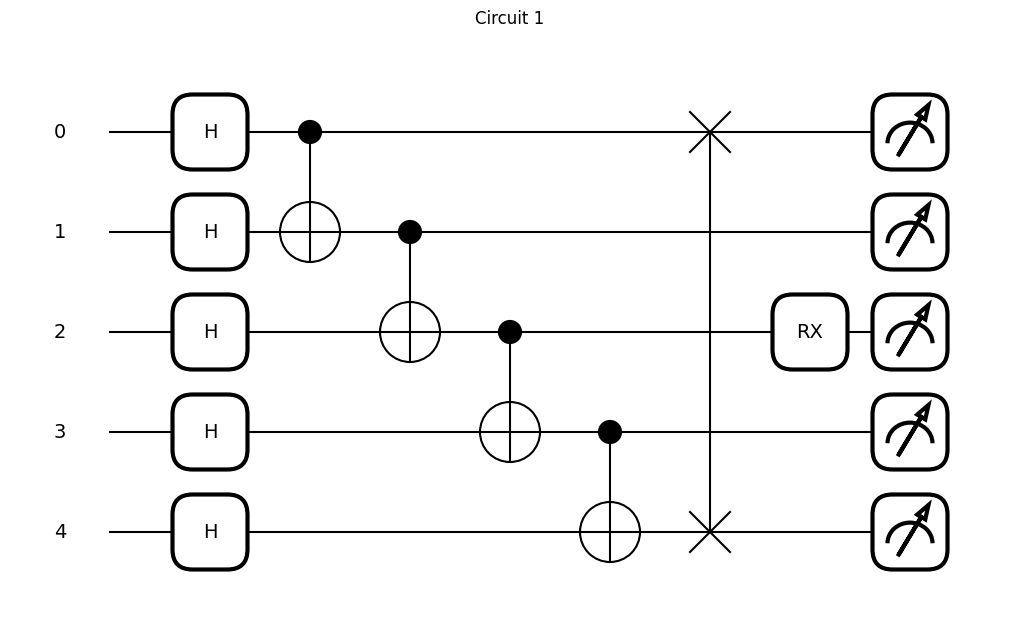

In [17]:
# Execute circuit
result = circuit_1()

# Plot the circuit
fig, ax = qml.draw_mpl(circuit_1)()
plt.title("Circuit 1")
plt.tight_layout()
plt.show()

## Part 2

In [18]:
dev2 = qml.device('default.qubit', wires=5)

@qml.qnode(dev2)
def circuit_2():

    # Hadamard on first qubit (wire 1)
    qml.Hadamard(wires=1)
    
    # Rotate second qubit (wire 2) by pi/3 around X
    qml.RX(np.pi/3, wires=2)
    
    # Hadamard on third and fourth qubit (wires 3, 4)
    qml.Hadamard(wires=3)
    qml.Hadamard(wires=4)
    
    # SWAP test
    
    # Step 1: Hadamard on ancilla
    qml.Hadamard(wires=0)
    
    # Step 2: Controlled-SWAP between the two registers
    qml.CSWAP(wires=[0, 1, 3])
    qml.CSWAP(wires=[0, 2, 4])
    
    # Step 3: Hadamard on ancilla
    qml.Hadamard(wires=0)
    
    # Measure ancilla - probability of |0> gives fidelity information
    return qml.probs(wires=0)

# Execute
probs = circuit_2()
fidelity = 2 * probs[0] - 1  # Fidelity = 2*P(0) - 1

/var/folders/sl/9jtd8vxd153ccx5_lhmdxm240000gn/T/ipykernel_10441/3226668719.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


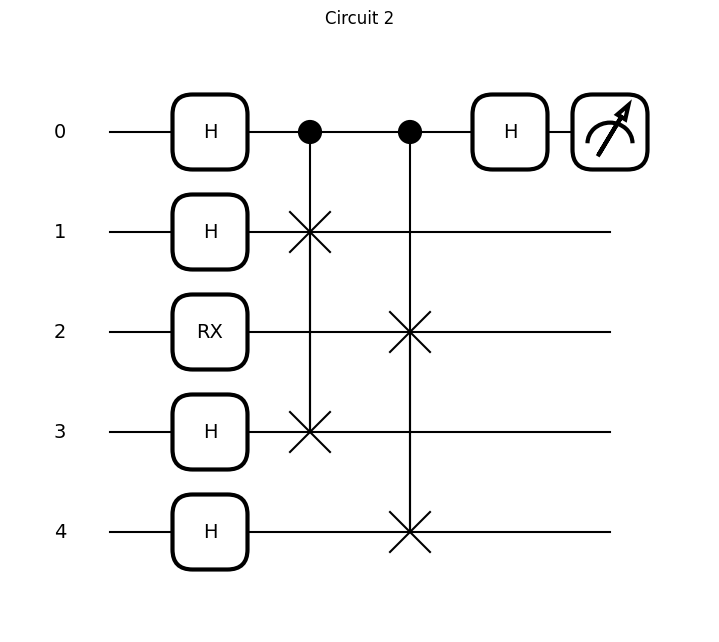

In [19]:
# Plot circuit 2
fig, ax = qml.draw_mpl(circuit_2)()
plt.title("Circuit 2")
plt.tight_layout()
plt.show()

In [20]:
# Display results
print(f"Ancilla measurement probabilities: P(0)={probs[0]:.4f}, P(1)={probs[1]:.4f}")
print(f"Estimated fidelity between |q1 q2> and |q3 q4>: {fidelity:.4f}")

Ancilla measurement probabilities: P(0)=0.7500, P(1)=0.2500
Estimated fidelity between |q1 q2> and |q3 q4>: 0.5000
